   ID  Video Duration Video Publish Time  Days Since Publish  Day  Month  \
0   0             201         2016-06-02                   0    2      6   
1   1             391         2016-06-10                   8   10      6   
2   2             133         2016-06-14                   4   14      6   
3   3              14         2016-06-29                  15   29      6   
4   4              45         2016-07-01                   2    1      7   

   Year Day of Week  Revenue per 1000 Views (USD)  \
0  2016    Thursday                         0.024   
1  2016      Friday                         0.056   
2  2016     Tuesday                         0.014   
3  2016   Wednesday                         0.004   
4  2016      Friday                         0.000   

   Monetized Playbacks (Estimate)  ...  Watched (Not Skipped) (%)  \
0                             723  ...                          0   
1                             727  ...                          0   
2                

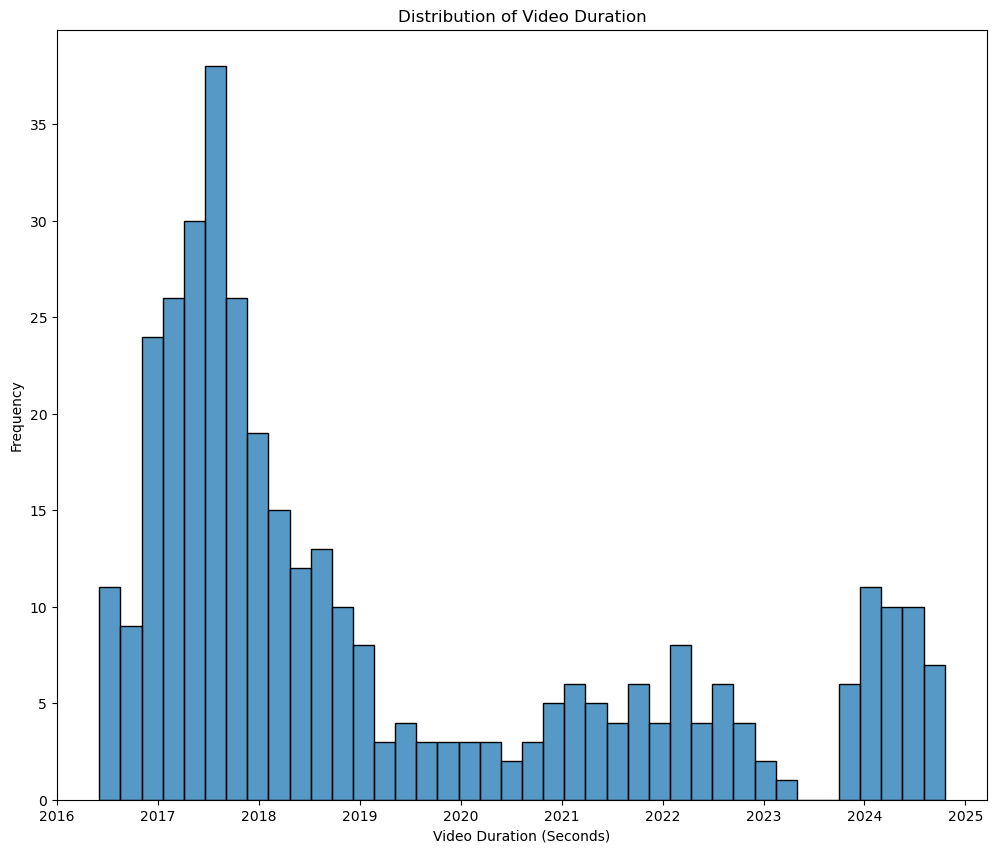

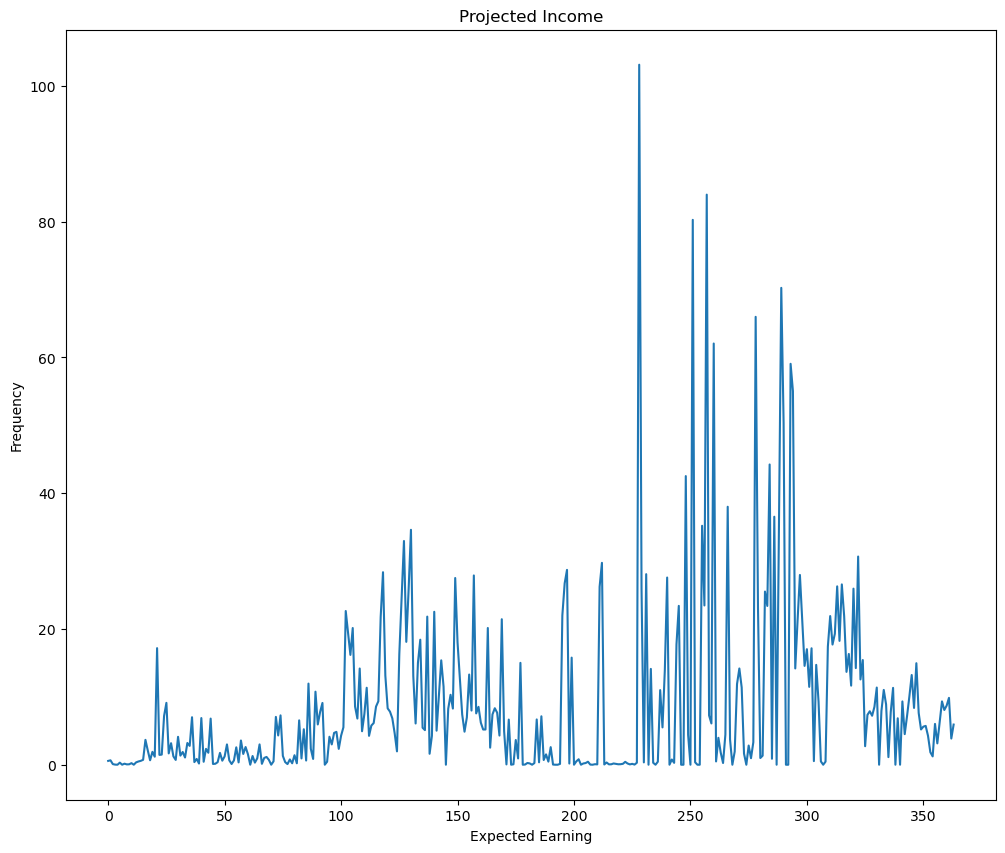

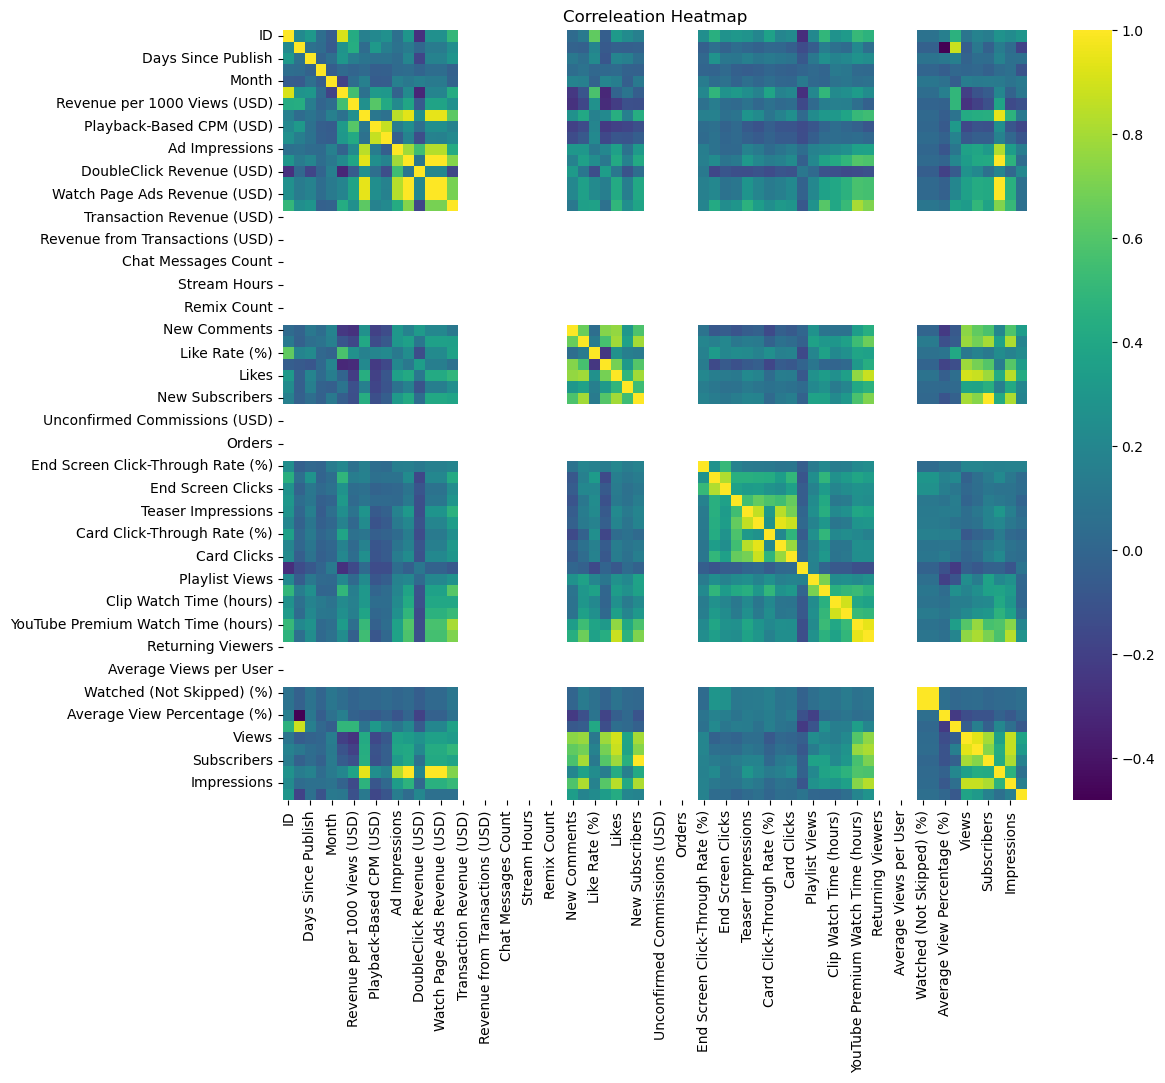

np.float64(2.1074789525781092)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
data = pd.read_excel('C:/Users/HP/Documents/DA_projects/youtube/youtube_channel.xlsx')
print(data.head())
print(data.tail())
# print(data.info())
print(data.columns)
print(data.describe())
print(data.isnull().sum())
print(data)
data['Video Publish Time'] = pd.to_datetime(data['Video Publish Time'])
plt.figure(figsize = (12,10))
sns.histplot(data['Video Publish Time'], bins = 40, kde = False)
plt.title('Distribution of Video Duration')
plt.xlabel('Video Duration (Seconds)')
plt.ylabel('Frequency')
plt.show()
plt.figure(figsize=(12,10))
sns.lineplot(data['Estimated Revenue (USD)'])
plt.title('Projected Income')
plt.xlabel('Expected Earning')
plt.ylabel('Frequency')
plt.show()
num = data.select_dtypes(include = [np.number])
corr = num.corr()
plt.figure(figsize = (12,10))
sns.heatmap(corr, cmap = 'viridis', fmt = '.2f', annot=False)
plt.title('Correleation Heatmap')
plt.show()
x = num.drop(columns =['Estimated Revenue (USD)'])
y = num['Estimated Revenue (USD)']
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.5, random_state = 50)
model = RandomForestRegressor(n_estimators = 120 ,random_state = 50)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
rmse

